In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import PercentFormatter
import plotly.graph_objects as go
from scipy.stats import fisher_exact
import numpy as np

In [4]:
df = pd.read_csv('ALL_collisions_elpaso_downtown_LPI_download.csv')

severity_values = {
    'K - FATAL INJURY': 13749500,
    'A - SUSPECTED SERIOUS INJURY': 1432400,
    'B - SUSPECTED MINOR INJURY': 303200,
    'C - POSSIBLE INJURY': 151600,
    'N - NOT INJURED': 0,
    '99 - UNKNOWN': 0
}

df["KABCO_USD_Value"] = df["Person_Injury_Severity"].map(severity_values).fillna(0)

In [5]:
# Ensure datetime
df["Crash_Date"] = pd.to_datetime(df["Crash_Date"])

# Define period boundaries
bins = [
    pd.Timestamp("2022-08-26"),
    pd.Timestamp("2023-08-26"),
    pd.Timestamp("2024-08-26"),
    pd.Timestamp("2025-08-26"),
    pd.Timestamp("2026-03-05")  # exclusive upper bound
]

labels = [
    "Aug 26 2022 - Aug 25 2023",
    "Aug 26 2023 - Aug 25 2024",
    "Aug 26 2024 - Aug 25 2025",
    "Aug 26 2025 - Mar 4 2026"
]

df["period_label"] = pd.cut(
    df["Crash_Date"],
    bins=bins,
    labels=labels,
    right=False  # include left date, exclude right date
)

In [6]:
# Ensure datetime
df["Crash_Date"] = pd.to_datetime(df["Crash_Date"])

# Create Pre vs Post LPI label
df["LPI_Period"] = df["Crash_Date"].apply(
    lambda x: "Pre LPI" if x < pd.Timestamp("2024-08-26") else "Post LPI"
)

# Optional: check result
df[["Crash_Date", "LPI_Period", "period_label"]].head()

,Crash_Date,LPI_Period,period_label
0,2022-09-09,Pre LPI,Aug 26 2022 - Aug 25 2023
1,2022-09-09,Pre LPI,Aug 26 2022 - Aug 25 2023
2,2022-09-21,Pre LPI,Aug 26 2022 - Aug 25 2023
3,2022-09-21,Pre LPI,Aug 26 2022 - Aug 25 2023
4,2022-10-06,Pre LPI,Aug 26 2022 - Aug 25 2023


In [7]:
groups = df.groupby('LPI_Period')

In [8]:
counts = (
    df
    .groupby(["LPI_Period", "Person_Injury_Severity"])
    .size()
    .reset_index(name="count")
    .pivot(index="LPI_Period", columns="Person_Injury_Severity", values="count")
)

# Make sure the LPI_Period order is Pre then Post
counts = counts.reindex(["Pre LPI", "Post LPI"])

counts

Person_Injury_Severity,99 - UNKNOWN,A - SUSPECTED SERIOUS INJURY,B - SUSPECTED MINOR INJURY,C - POSSIBLE INJURY,N - NOT INJURED
LPI_Period,,,,,
Pre LPI,22.0,5.0,55.0,28.0,333.0
Post LPI,7.0,NaN,11.0,15.0,175.0


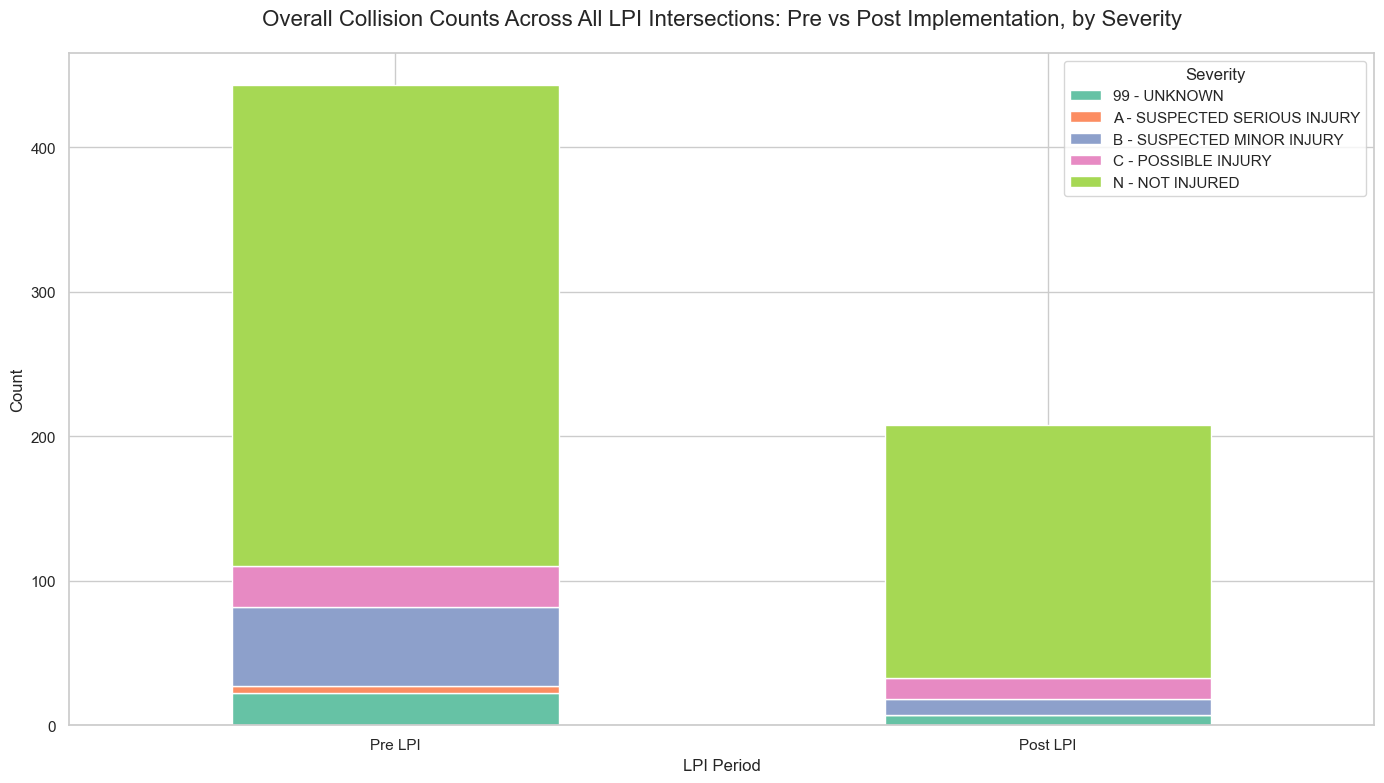

In [9]:
sns.set_theme(style="whitegrid")

# Create Set2 color palette
colors = sns.color_palette("Set2", n_colors=len(counts.columns))

ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8),
    color=colors   # 👈 Apply Set2 colors
)

ax.set_xlabel("LPI Period")
ax.set_ylabel("Count")

# Improved, Council-friendly title
ax.set_title(
    "Overall Collision Counts Across All LPI Intersections: Pre vs Post Implementation, by Severity",
    fontsize=16,
    pad=20
)

# Keep x labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
ax.legend(title="Severity")

plt.tight_layout()
plt.show()

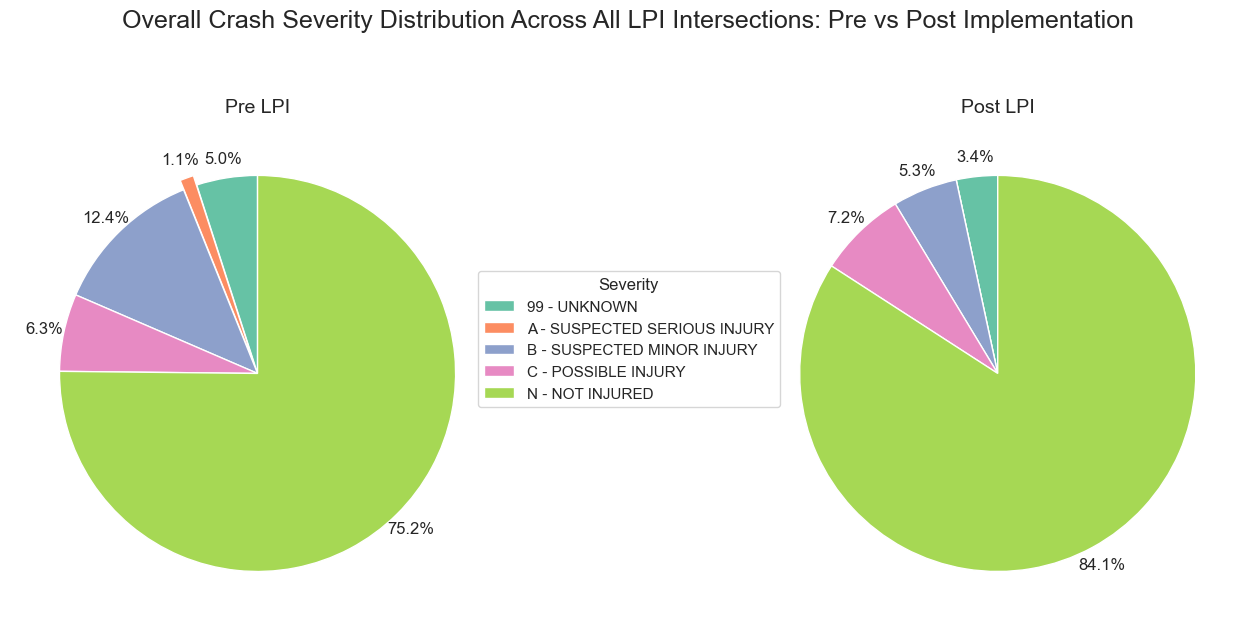

In [10]:
# Convert counts to percentages
percentages = counts.div(counts.sum(axis=1), axis=0)

# Remove zero-sum rows (just in case)
percentages = percentages[percentages.sum(axis=1) > 0]

n_periods = len(percentages)

# Set color palette
colors = sns.color_palette("Set2", n_colors=len(percentages.columns))

# ------------------------------
# Function to show percentages only if >0
def autopct_no_zero(p):
    return f"{p:.1f}%" if p > 0 else ""

# ------------------------------
# Create figure
fig, axes = plt.subplots(1, n_periods, figsize=(8 * n_periods, 6))
if n_periods == 1:
    axes = [axes]

for ax, (period, row) in zip(axes, percentages.iterrows()):
    values = np.nan_to_num(row.values.astype(float))
    
    # Explode small slices (<2%) slightly
    explode = [0.05 if v < 0.02 else 0 for v in values]
    
    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,            # hide labels on slices
        autopct=autopct_no_zero,
        startangle=90,
        colors=colors,
        pctdistance=1.1,        # move % labels outside
        explode=explode
    )
    
    # Subtitle for each period
    ax.set_title(period, fontsize=14, pad=10)

# ------------------------------
# Overall chart title
fig.suptitle(
    "Overall Crash Severity Distribution Across All LPI Intersections: Pre vs Post Implementation",
    fontsize=18,
    y=1.05
)

# ------------------------------
# Legend
fig.legend(
    wedges,
    percentages.columns,
    title="Severity",
    loc="center right",
    bbox_to_anchor=(0.6, 0.5)
)

plt.tight_layout()
plt.show()

C:\Users\CastroJG\AppData\Local\Temp\ipykernel_2080\2869963567.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


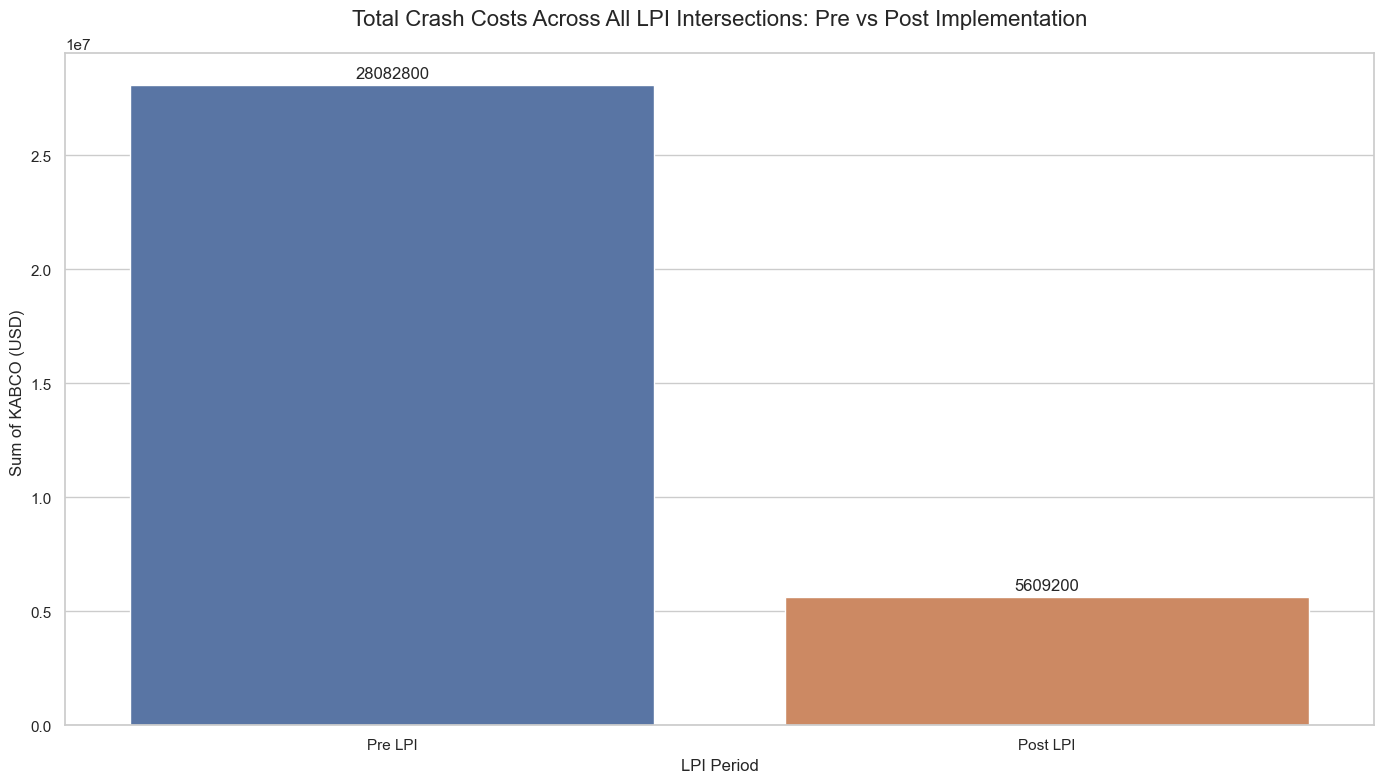

In [11]:
# Compute the data first
kabco_sum = groups["KABCO_USD_Value"].sum().reset_index()
kabco_sum.columns = ["KABCO_USD_Value", "sum_kabco"]

# Make sure the x-axis order is Pre then Post
order = ["Pre LPI", "Post LPI"]

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=kabco_sum,
    x="KABCO_USD_Value",
    y="sum_kabco",
    ci=None,
    order=order  # 👈 Force the correct order
)

# Axis labels and title
ax.set_xlabel("LPI Period")
ax.set_ylabel("Sum of KABCO (USD) ")
ax.set_title(
    "Total Crash Costs Across All LPI Intersections: Pre vs Post Implementation",
    fontsize=16,
    pad=20
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [12]:
# 1️⃣ Aggregate counts by Period_Label and Severity
severity_counts = df.groupby(['period_label','Crash_Severity']).size().unstack(fill_value=0)

# 2️⃣ Collapse categories: Severe (A/B) vs Non-severe (C/N)
severity_counts['Severe'] = severity_counts.get('A - SUSPECTED SERIOUS INJURY',0) + \
                            severity_counts.get('B - SUSPECTED MINOR INJURY',0)
severity_counts['Non_Severe'] = severity_counts.get('C - POSSIBLE INJURY',0) + \
                                severity_counts.get('N - NOT INJURED',0)

table_2x2 = severity_counts[['Severe','Non_Severe']].copy()

# Ensure consistent ordering (important)
table_2x2 = table_2x2.sort_index()

# Explicitly define periods
pre_periods = [
    "Aug 26 2022 - Aug 25 2023",
    "Aug 26 2023 - Aug 25 2024"
]

post_periods = [
    "Aug 26 2024 - Aug 25 2025",
    "Aug 26 2025 - Mar 4 2026"
]

# Aggregate counts
pre = table_2x2.loc[pre_periods].sum().values
post = table_2x2.loc[post_periods].sum().values

# Build contingency table
contingency = np.array([pre, post])

print("Contingency Table:")
print(contingency)

# Fisher's Exact Test
oddsratio, p_value = fisher_exact(contingency, alternative='two-sided')

print(f"\nFisher's exact test:")
print(f"Odds ratio = {oddsratio:.3f}")
print(f"P-value = {p_value:.4f}")

Contingency Table:
[[118 323]
 [ 28 180]]

Fisher's exact test:
Odds ratio = 2.349
P-value = 0.0001


In [72]:
# Canonical intersection key
df["Street_A"] = np.minimum(df["Street_Name"], df["Intersecting_Street_Name"])
df["Street_B"] = np.maximum(df["Street_Name"], df["Intersecting_Street_Name"])
df["Full_Intersection"] = df["Street_A"] + " & " + df["Street_B"]

# ---- 1. Aggregate KABCO_USD_Value by period ----
agg = (
    df.groupby(["LPI_Period", "Full_Intersection"], as_index=False)
      .agg({"KABCO_USD_Value": "sum"})
)

# ---- 2. Pivot to wide format ----
pivot = (
    agg.pivot(
        index="Full_Intersection",
        columns="LPI_Period",
        values="KABCO_USD_Value"
    )
    .fillna(0)
)

# Ensure both periods exist
pivot = pivot.reindex(columns=["Pre LPI", "Post LPI"], fill_value=0)

# ---- 3. Compute absolute and percent change ----
pivot["Absolute_Change"] = pivot["Post LPI"] - pivot["Pre LPI"]
pivot["Percent_Change"] = (
    (pivot["Post LPI"] - pivot["Pre LPI"]) / pivot["Pre LPI"]
).replace([np.inf, -np.inf], np.nan) * 100

# ---- 4. Compute mean coordinates per intersection ----
coords = (
    df.groupby("Full_Intersection", as_index=False)
      .agg({
          "Latitude": "mean",
          "Longitude": "mean"
      })
)

# ---- 5. Merge coordinates into pivot ----
pivot = pivot.reset_index().merge(coords, on="Full_Intersection", how="left")


pivot['Scaled_Pre_LPI'] = pivot['Pre LPI'].astype(float) / pivot['Pre LPI'].max()
pivot['Scaled_Post_LPI'] = pivot['Post LPI'].astype(float) / pivot['Pre LPI'].max()

# ---- 6. Sort by absolute change ----
pivot = pivot.sort_values(["Scaled_Pre_LPI", "Scaled_Post_LPI"], ascending=False)

In [67]:
# Create a custom Viridis-like scale without yellow
# Viridis goes from dark purple → blue → green → yellow
# We'll keep dark purple → blue → green, skip the yellow

# If you want no yellow at all, replace the last color with a darker green
viridis_no_yellow = [
    [0.0, "#440154"],  # dark purple
    [0.25, "#3b528b"], # dark blue
    [0.5, "#21918c"],  # teal
    [0.75, "#35b778"], # green
    [1.0, "#5ec962"]   # darker green instead of yellow
]

blue_orange = [
    [0.0, "#08306b"],  # dark blue
    [0.2, "#2171b5"],  # medium blue
    [0.4, "#6baed6"],  # light blue
    [0.5, "#ffffff"],  # white in the middle
    [0.6, "#fdae6b"],  # light orange
    [0.8, "#e6550d"],  # medium orange
    [1.0, "#99000d"]   # dark orange
]

In [122]:
discrete_scale = [
    [0.0,"#440154"],
    [0.2,"#440154"],
    [0.2,"#3b528b"],
    [0.4,"#3b528b"],
    [0.4,"#21918c"],
    [0.6,"#21918c"],
    [0.6,"#35b778"],
    [0.8,"#35b778"],
    [0.8,"#5ec962"],
    [1.0,"#5ec962"]
]

discrete_scale = [
    [0.0,  "#440154"],
    [0.1667,"#440154"],

    [0.1667,"#414487"],
    [0.3333,"#414487"],

    [0.3333,"#2a788e"],
    [0.5,   "#2a788e"],

    [0.5,   "#21918c"],
    [0.6667,"#21918c"],

    [0.6667,"#35b778"],
    [0.8333,"#35b778"],

    [0.8333,"#5ec962"],
    [1.0,   "#5ec962"]
]

discrete_scale = [
    [0.0,   "#0b3c5d"],
    [0.1667,"#0b3c5d"],

    [0.1667,"#1f5f8b"],
    [0.3333,"#1f5f8b"],

    [0.3333,"#3a7ca5"],
    [0.5,   "#3a7ca5"],

    [0.5,   "#6c8ebf"],
    [0.6667,"#6c8ebf"],

    [0.6667,"#e28743"],
    [0.8333,"#e28743"],

    [0.8333,"#b85c0a"],
    [1.0,   "#b85c0a"]
]

discrete_scale = [
    [0.0,   "#0b3c5d"],
    [0.1667,"#0b3c5d"],

    [0.1667,"#3a7ca5"],
    [0.3333,"#3a7ca5"],

    [0.3333,"#6c8ebf"],
    [0.5,   "#6c8ebf"],

    [0.5,   "#e28743"],
    [0.6667,"#e28743"],

    [0.6667,"#d66a1f"],
    [0.8333,"#d66a1f"],

    [0.8333,"#b85c0a"],
    [1.0,   "#b85c0a"]
]

In [123]:
# 10 evenly spaced tick values from 0 to pre_max
tick_vals = np.linspace(0, 6000000, 6)
tick_text = [f"{int(v):,}" for v in tick_vals]  # formatted with commas

In [ ]:
ColorVariable = discrete_scale
mapStyle = "carto-positron"

pre_max = pivot['Pre LPI'].max()

fig = go.Figure()

# ---- Pre LPI series (with colorbar) ----
fig.add_trace(go.Scattermapbox(
    lat=pivot['Latitude'],
    lon=pivot['Longitude'],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=20,
        color=pivot['Pre LPI'],
        colorscale=ColorVariable,
        cmin=0,
        cmax=pre_max,
        showscale=True,
        colorbar=dict(
            title='KABCO sum (USD)',
            orientation='h',
            x=0.5,
            y=-0.1,
            len=0.9
        )
    ),
    text=pivot['Full_Intersection'],
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Pre LPI KABCO sum USD: %{marker.color}<br>"
        "Post LPI KABCO sum USD: %{customdata[0]}"
    ),
    customdata=pivot[['Post LPI']],
    name='Pre LPI KABCO sum USD'
))

# ---- Post LPI series (no colorbar) ----
fig.add_trace(go.Scattermapbox(
    lat=pivot['Latitude'],
    lon=pivot['Longitude'],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=20,
        color=pivot['Post LPI'],
        colorscale=ColorVariable,
        cmin=0,
        cmax=pre_max,  # same scale as Pre
        showscale=True,
        colorbar=dict(
            title='KABCO sum (USD)',
            orientation='h',
            x=0.5,
            y=-0.1,
            len=0.9
        )
    ),
    text=pivot['Full_Intersection'],
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Pre LPI KABCO sum USD: %{customdata[0]}<br>"
        "Post LPI KABCO sum USD: %{marker.color}"
    ),
    customdata=pivot[['Pre LPI']],
    name='Post LPI KABCO sum USD'
))

# ---- Layout ----
fig.update_layout(
    mapbox_style=mapStyle,
    mapbox_zoom=15,
    mapbox_center={"lat": pivot["Latitude"].mean(), "lon": pivot["Longitude"].mean()},
    title=dict(
        text="<b>Crash Cost Intensity at LPI Intersections: Post LPI Implementation</b>",
        font=dict(size=20),
        y=0.99,                  # slightly lower than the top (default is 1.0)
        pad=dict(t=5, b=0)      # add 20px padding on top
    ),
    margin={"r":0,"t":30,"l":0,"b":50},  # extra margin at top (t)
    legend=dict(title="Crash Cost Series")
)

# Add north arrow (text "N") in top-right corner
fig.add_annotation(
    x=0.95,  # relative position (0 = left, 1 = right)
    y=0.95,  # relative position (0 = bottom, 1 = top)
    xref="paper",
    yref="paper",
    text="⬆ N",
    showarrow=False,
    font=dict(size=30, color="black"),
    align="center"
)

# ---- Show map ----
fig.show(renderer="browser")